In [154]:
import pandas as pd
import json
from level_functions import *
import matplotlib.pyplot as plt
import numpy as np


In [155]:
commentedCosts = {
    'Common': {
        'xp': {
            250: 7359,  
            300: 3906,
            350: 5663,
            400: 8218,
            450: 11931,
            500: 17325,
            550: 25160,
            600: 36547,
            650: 53087,
            700: 77124,
            750: 112041,
            800: 162728, # predicted, exact value = 162728.124318
            850: 236346,
            900: 343268, # predicted, exact value = 343268.457708
            950: 498562, # predicted, exact value = 498562.421438
            1000: 724111, # predicted, exact value = 724111.063772
        },
        'gems': {
            250: 0,
            300: 40,  
            350: 60,
            400: 80,
            450: 100,
            500: 125,
            550: 150,
            600: 200,
            650: 275,
            700: 350,
            750: 500,
            800: 550,
            850: 600,
            900: 650,
            950: 700, # predicted
            1000: 750, # predicted
        }
    },
    'Rare': {
        'xp': {
            250: 8806,
            300: 4681,
            350: 6798,
            400: 9859,
            450: 14311,
            500: 20786,
            550: 30189,
            600: 43847,
            650: 63702,
            700: 92543,
            750: 134448,
            800: 195272,
            850: 283612, # predicted, exact value = 283612.671412
            900: 411918, # predicted, exact value = 411918.476733
            950: 598270, # predicted, exact value = 598269.571771
            1000: 868926, # predicted, exact value = 868925.5295
        },
        'gems': {
            250: 0,
            300: 80,
            350: 120,
            400: 160,
            450: 200,
            500: 250,
            550: 300,
            600: 400,
            650: 550,
            700: 700,
            750: 1000,
            850: 1800,
            900: 1950,
            950: 2100, # predicted
            1000: 2250, # predicted
        }
    },
    'Epic': {
        'xp': { #exponential growth : r=1.452398 every 50 levels
            250: 10255,
            300: 5459,
            350: 7918,
            400: 11494,
            450: 16695,
            500: 24245,
            550: 35213,
            600: 51152,
            650: 74309,
            700: 107964,
            750: 156850,
            800: 227884,
            850: 331099,
            900: 480888, # predicted, exact value = 480887.525402
            950: 698440, # predicted, exact value = 698440.080119
            1000: 1014413, # predicted, exact value = 1014412.97548
        },
        'gems': {
            250: 0,
            300: 120,
            350: 180,
            400: 240,
            450: 300,
            500: 375,
            550: 450,
            600: 600,
            650: 825,
            700: 1050,
            750: 1500,
            800: 1650,
            850: 1800,
            900: 1950,
            950: 2100, # predicted
            1000: 2250, # predicted
        }
    },
    'Legendary': {
        'xp': { #exponential growth : r=1.452398 every 50 levels
            250: 11703,
            300: 6233,
            350: 9048,
            400: 13135,
            450: 19072,
            500: 27705,
            550: 40241,
            600: 58458,
            650: 84924,
            700: 123378,
            750: 179252,
            800: 260438,
            850: 378390,
            900: 549573, # predicted, exact value = 549572.87922
            950: 798199, # predicted, exact value = 798198.550633
            1000: 1159302, # predicted, exact value = 1159301.97854
        },
        'gems': {
            250: 0,
            300: 160,
            350: 240,
            400: 320,
            450: 400,
            500: 500,
            550: 600,
            600: 800,
            650: 1100,
            700: 1400,
            750: 2000,
            800: 2200,
            850: 2400,
            900: 2600,
            950: 2800, # predicted
            1000: 3000, # predicted
        }
    },
    'Mythic': {
        'xp': {
            250: 29073,
            300: 15544,
            350: 22581,
            400: 32804,
            450: 47652,
            500: 69221,
            550: 100567,
            600: 146104,
            650: 212274,
            700: 308413,
            750: 448100,
        },
        'gems': {
            250: 0,
            300: 200,
            350: 300,
            400: 400,
            450: 500,
            500: 625,
            550: 750,
            600: 1000,
            650: 1375,
            700: 1750,
            750: 2500,
        }
    }
}


In [156]:
with open('level_costs.json', 'r') as f:
    costs = json.load(f)

for rarity in costs:
    costs[rarity]['xp'] = {int(k): v for k, v in costs[rarity]['xp'].items()}
    costs[rarity]['gems'] = {int(k): v for k, v in costs[rarity]['gems'].items()}

In [157]:
xp_cost = get_cost(costs, 'Legendary', 500, 'xp')  # Returns 27705
print(xp_cost)
gems_cost = get_cost(costs, 'Legendary', 500, 'gems')  # Returns 500
print(gems_cost)

27705
500


In [158]:
def pretty_cost(rarity, start, end, cost):
    """Print aligned cost data"""
    
    print(f"{rarity} Start at {start:>4} → {end:<4}: {cost:>9} xp")

# Examples for Legendary
pretty_cost("Legendary", 0, 750,      format_number(sum_xp_from_start(costs, "Legendary", 0, 750)))
pretty_cost("Legendary", 250, 1000,   format_number(sum_xp_from_start(costs, "Legendary", 250, 1000)))
pretty_cost("Legendary", 1000, 1000,  format_number(sum_xp_from_start(costs, "Legendary", 1000, 1000)))
pretty_cost("Legendary", 350, 400,    format_number(sum_xp_from_start(costs, "Legendary", 350, 400)))
pretty_cost("Legendary", 0, 800,      format_number(sum_xp_from_start(costs, "Legendary", 0, 800)))

Legendary Start at    0 → 750 :   573 149 xp
Legendary Start at  250 → 1000: 3 707 348 xp
Legendary Start at 1000 → 1000:         0 xp
Legendary Start at  350 → 400 :    13 135 xp
Legendary Start at    0 → 800 :   833 587 xp


In [159]:
unlock_caps = {
    'level_cap': [250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000],
    'girls_needed_to_reach_it': [0, 20, 25, 30, 35, 40, 50, 60, 70, 85, 100, 110, 120, 130, 140, 150]
}

unlock_caps = pd.DataFrame(unlock_caps)
print(unlock_caps)

    level_cap  girls_needed_to_reach_it
0         250                         0
1         300                        20
2         350                        25
3         400                        30
4         450                        35
5         500                        40
6         550                        50
7         600                        60
8         650                        70
9         700                        85
10        750                       100
11        800                       110
12        850                       120
13        900                       130
14        950                       140
15       1000                       150


In [160]:
rarity_limits = which_girls_for_cap(unlock_caps, 850, {'Common': 25, 'Rare': 78, 'Epic': 109, 'Legendary': 999999, 'Mythic': 999999})
rarity_limits

{'Common': 25, 'Rare': 78, 'Epic': 17, 'Legendary': 0, 'Mythic': 0}

In [161]:
print("Commons   : " + format_number(sum_xp_from_start(costs, "Common", 0, 750)))
print("Legendary : " + format_number(sum_xp_from_start(costs, "Legendary", 0, 750)))

Commons   : 358 361
Legendary : 573 149


In [162]:
total_cumulative_cost_for_cap(costs, unlock_caps, 750, rarity_limits, min_requirements=None)

(28322150,
 241500,
 {'Common': 25, 'Rare': 75, 'Epic': 0, 'Legendary': 0, 'Mythic': 0})

In [163]:
print(format_number(sum_xp_from_start(costs, "Common", 0, 700)*25 + sum_xp_from_start(costs, "Rare", 0, 700)*75))

28 322 150


In [164]:
print(format_number(28322150))
print(format_number(241500))

28 322 150
241 500


In [165]:
# For cap 750, with min requirements
min_req = {'Legendary': 7}
rarity_limits = {'Common': 25, 'Rare': 78, 'Epic': 109, 'Legendary': 999999, 'Mythic': 999999}

print_cumulative_summary(costs, unlock_caps, 750, rarity_limits, min_req)


  To unlock level cap 750
   Need 100 girls at level 700
  Girl allocation (from level 0 to 700):
   • Common    :  25 girls  (XP: 358 361 each, Gems: 1880 each)
   • Rare      :  68 girls  (XP: 429 970 each, Gems: 3760 each)
   • Legendary :   7 girls  (XP: 573 149 each, Gems: 7520 each)

  TOTAL Cumulative Cost to unlock lvl 750 cap):
   • XP : 29 010 775
   • Gems: 260 820



(29010775,
 260820,
 {'Common': 25, 'Rare': 68, 'Epic': 0, 'Legendary': 7, 'Mythic': 0})

In [166]:
# For cap 800, with min requirements
min_req = {'Legendary': 7}
rarity_limits = {'Common': 25, 'Rare': 78, 'Epic': 109, 'Legendary': 999999, 'Mythic': 999999}

print_cumulative_summary(costs, unlock_caps, 800, rarity_limits, min_req)


  To unlock level cap 800
   Need 110 girls at level 750
  Girl allocation (from level 0 to 750):
   • Common    :  25 girls  (XP: 521 089 each, Gems: 2430 each)
   • Rare      :  78 girls  (XP: 625 242 each, Gems: 3760 each)
   • Legendary :   7 girls  (XP: 833 587 each, Gems: 9720 each)

  TOTAL Cumulative Cost to unlock lvl 800 cap):
   • XP : 46 508 728
   • Gems: 392 920



(46508728,
 392920,
 {'Common': 25, 'Rare': 78, 'Epic': 0, 'Legendary': 7, 'Mythic': 0})

In [167]:
print_cumulative_summary(costs, unlock_caps, 850, rarity_limits, min_req)


  To unlock level cap 850
   Need 120 girls at level 800
  Girl allocation (from level 0 to 800):
   • Common    :  25 girls  (XP: 757 435 each, Gems: 3030 each)
   • Rare      :  78 girls  (XP: 908 854 each, Gems: 5560 each)
   • Epic      :  10 girls  (XP: 1 060 537 each, Gems: 9090 each)
   • Legendary :   7 girls  (XP: 1 211 977 each, Gems: 12120 each)

  TOTAL Cumulative Cost to unlock lvl 850 cap):
   • XP : 74 925 590
   • Gems: 494 970



(74925590,
 494970,
 {'Common': 25, 'Rare': 78, 'Epic': 10, 'Legendary': 7, 'Mythic': 0})

In [168]:
# Define your limits
rarity_limits = {
    'Common': 25,
    'Rare': 78,
    'Epic': 109,
    'Legendary': 999999,
    'Mythic': 999999
}

# Min requirements
min_req = {'Legendary': 7}

# Cost to unlock 800 from 750
unlock_xp, unlock_gems = print_unlock_from_another_cap(costs, unlock_caps, 800, 850, rarity_limits, min_req)


🔓 UNLOCK TIER: 800 → 850
📈 Additional Resources Needed:
   • XP   : 28 416 862
   • Gems : 102 050



In [169]:
print_cumulative_summary(costs, unlock_caps, 850, rarity_limits, {'Legendary': 7})


  To unlock level cap 850
   Need 120 girls at level 800
  Girl allocation (from level 0 to 800):
   • Common    :  25 girls  (XP: 757 435 each, Gems: 3030 each)
   • Rare      :  78 girls  (XP: 908 854 each, Gems: 5560 each)
   • Epic      :  10 girls  (XP: 1 060 537 each, Gems: 9090 each)
   • Legendary :   7 girls  (XP: 1 211 977 each, Gems: 12120 each)

  TOTAL Cumulative Cost to unlock lvl 850 cap):
   • XP : 74 925 590
   • Gems: 494 970



(74925590,
 494970,
 {'Common': 25, 'Rare': 78, 'Epic': 10, 'Legendary': 7, 'Mythic': 0})

In [170]:
print("Common : " + format_number(sum_xp_from_start(costs, "Common", 750, 800)))
print("25 Commons : " + format_number(sum_xp_from_start(costs, "Common", 750, 800)*25))

Common : 162 728
25 Commons : 4 068 200


In [171]:
# Define your limits
rarity_limits = {
    'Common': 99999,
    'Rare': 78,
    'Epic': 109,
    'Legendary': 999999,
    'Mythic': 999999
}

# Min requirements
min_req = {'Legendary': 7}

# Cost to unlock 800 from 750
unlock_xp, unlock_gems = print_unlock_from_another_cap(costs, unlock_caps, 650, 700, rarity_limits, min_req)


🔓 UNLOCK TIER: 650 → 700
📈 Additional Resources Needed:
   • XP   : 6 476 889
   • Gems : 40 475



In [172]:
print_cumulative_summary(costs, unlock_caps, 700, rarity_limits, {'Legendary': 7})


  To unlock level cap 700
   Need 85 girls at level 650
  Girl allocation (from level 0 to 650):
   • Common    :  78 girls  (XP: 246 320 each, Gems: 1380 each)
   • Legendary :   7 girls  (XP: 393 897 each, Gems: 5520 each)

  TOTAL Cumulative Cost to unlock lvl 700 cap):
   • XP : 15 090 921
   • Gems: 109 180



(15090921,
 109180,
 {'Common': 78, 'Rare': 0, 'Epic': 0, 'Legendary': 7, 'Mythic': 0})

In [173]:
format_number(sum_xp_from_start(costs, "Common", 0, 700))

'246 320'

In [174]:
total_cumulative_cost_for_cap(costs, unlock_caps, 700, rarity_limits, {'Legendary': 7})

(15090921,
 109180,
 {'Common': 78, 'Rare': 0, 'Epic': 0, 'Legendary': 7, 'Mythic': 0})

In [175]:
def compare_compositions(costs, unlock_caps, rarity_limits, 
                        comp1_name, comp1_min_reqs,
                        comp2_name, comp2_min_reqs,
                        caps=range(250, 801, 50)):  # 250, 300, 350...800
    """
    Compare two compositions across multiple level caps.
    
    Returns DataFrame with results for each cap.
    """
    results = []
    
    for cap in caps:
        # Get results for comp1
        xp1, gems1, comp1 = total_cumulative_cost_for_cap(
            costs, unlock_caps, cap, rarity_limits, comp1_min_reqs
        )
        
        # Get results for comp2
        xp2, gems2, comp2 = total_cumulative_cost_for_cap(
            costs, unlock_caps, cap, rarity_limits, comp2_min_reqs
        )
        
        results.append({
            'Level Cap': cap,
            f'{comp1_name}_XP': xp1,
            f'{comp1_name}_Gems': gems1,
            f'{comp2_name}_XP': xp2,
            f'{comp2_name}_Gems': gems2,
            'XP_Difference': xp1 - xp2,
            'Gems_Difference': gems1 - gems2,
            f'{comp1_name}_Composition': comp1,
            f'{comp2_name}_Composition': comp2
        })
    
    return pd.DataFrame(results)

# Usage example
df = compare_compositions(
    costs, unlock_caps, rarity_limits,
    comp1_name='Legendary_30',
    comp1_min_reqs={'Legendary': 30},
    comp2_name='Default',
    comp2_min_reqs=None,
    caps=range(250, 801, 50)
)

In [176]:
def display_pretty_table(df, cap_range=None):
    """Display formatted comparison table"""
    
    # Select columns for display
    display_cols = ['Level Cap', 'Legendary_30_XP', 'Default_XP', 
                    'XP_Difference', 'Legendary_30_Gems', 'Default_Gems', 'Gems_Difference']
    
    if cap_range:
        df_display = df[df['Level Cap'].isin(cap_range)].copy()
    else:
        df_display = df.copy()
    
    # Format numbers with thousand separators
    for col in ['Legendary_30_XP', 'Default_XP', 'XP_Difference',
                'Legendary_30_Gems', 'Default_Gems', 'Gems_Difference']:
        if col in df_display.columns:
            df_display[col] = df_display[col].apply(lambda x: f"{x:,.0f}")
    
    # Add sign indicators for differences
    df_display['XP_Diff_Sign'] = df_display['XP_Difference'].apply(
        lambda x: f"+{x}" if not x.startswith('-') and x != '0' else x
    )
    df_display['Gems_Diff_Sign'] = df_display['Gems_Difference'].apply(
        lambda x: f"+{x}" if not x.startswith('-') and x != '0' else x
    )
    
    return df_display

# Display as plain DataFrame
display(display_pretty_table(df))

,Level Cap,Legendary_30_XP,Legendary_30_Gems,Default_XP,Default_Gems,XP_Difference,Gems_Difference,Legendary_30_Composition,Default_Composition,XP_Diff_Sign,Gems_Diff_Sign
0,250,0,0,0,0,0,0,"{'Common': 0, 'Rare': 0, 'Epic': 0, 'Legendary...","{'Common': 0, 'Rare': 0, 'Epic': 0, 'Legendary...",0,0
1,300,"234,060",0,"147,180",0,"86,880",0,"{'Common': 0, 'Rare': 0, 'Epic': 0, 'Legendary...","{'Common': 20, 'Rare': 0, 'Epic': 0, 'Legendar...","+86,880",0
2,350,"448,400","4,000","281,625","1,000","166,775","3,000","{'Common': 0, 'Rare': 0, 'Epic': 0, 'Legendary...","{'Common': 25, 'Rare': 0, 'Epic': 0, 'Legendar...","+166,775","+3,000"
3,400,"809,520","12,000","507,840","3,000","301,680","9,000","{'Common': 0, 'Rare': 0, 'Epic': 0, 'Legendary...","{'Common': 30, 'Rare': 0, 'Epic': 0, 'Legendar...","+301,680","+9,000"
4,450,"1,329,300","22,500","880,110","6,300","449,190","16,200","{'Common': 5, 'Rare': 0, 'Epic': 0, 'Legendary...","{'Common': 35, 'Rare': 0, 'Epic': 0, 'Legendar...","+449,190","+16,200"
5,500,"2,146,500","36,400","1,483,080","11,200","663,420","25,200","{'Common': 10, 'Rare': 0, 'Epic': 0, 'Legendar...","{'Common': 40, 'Rare': 0, 'Epic': 0, 'Legendar...","+663,420","+25,200"
6,550,"3,694,920","56,700","2,720,100","20,250","974,820","36,450","{'Common': 20, 'Rare': 0, 'Epic': 0, 'Legendar...","{'Common': 50, 'Rare': 0, 'Epic': 0, 'Legendar...","+974,820","+36,450"
7,600,"6,200,970","83,250","4,773,720","33,300","1,427,250","49,950","{'Common': 30, 'Rare': 0, 'Epic': 0, 'Legendar...","{'Common': 60, 'Rare': 0, 'Epic': 0, 'Legendar...","+1,427,250","+49,950"
8,650,"10,212,210","120,800","8,127,630","52,850","2,084,580","67,950","{'Common': 40, 'Rare': 0, 'Epic': 0, 'Legendar...","{'Common': 70, 'Rare': 0, 'Epic': 0, 'Legendar...","+2,084,580","+67,950"
9,700,"17,421,350","180,250","14,381,660","87,550","3,039,690","92,700","{'Common': 55, 'Rare': 0, 'Epic': 0, 'Legendar...","{'Common': 85, 'Rare': 0, 'Epic': 0, 'Legendar...","+3,039,690","+92,700"


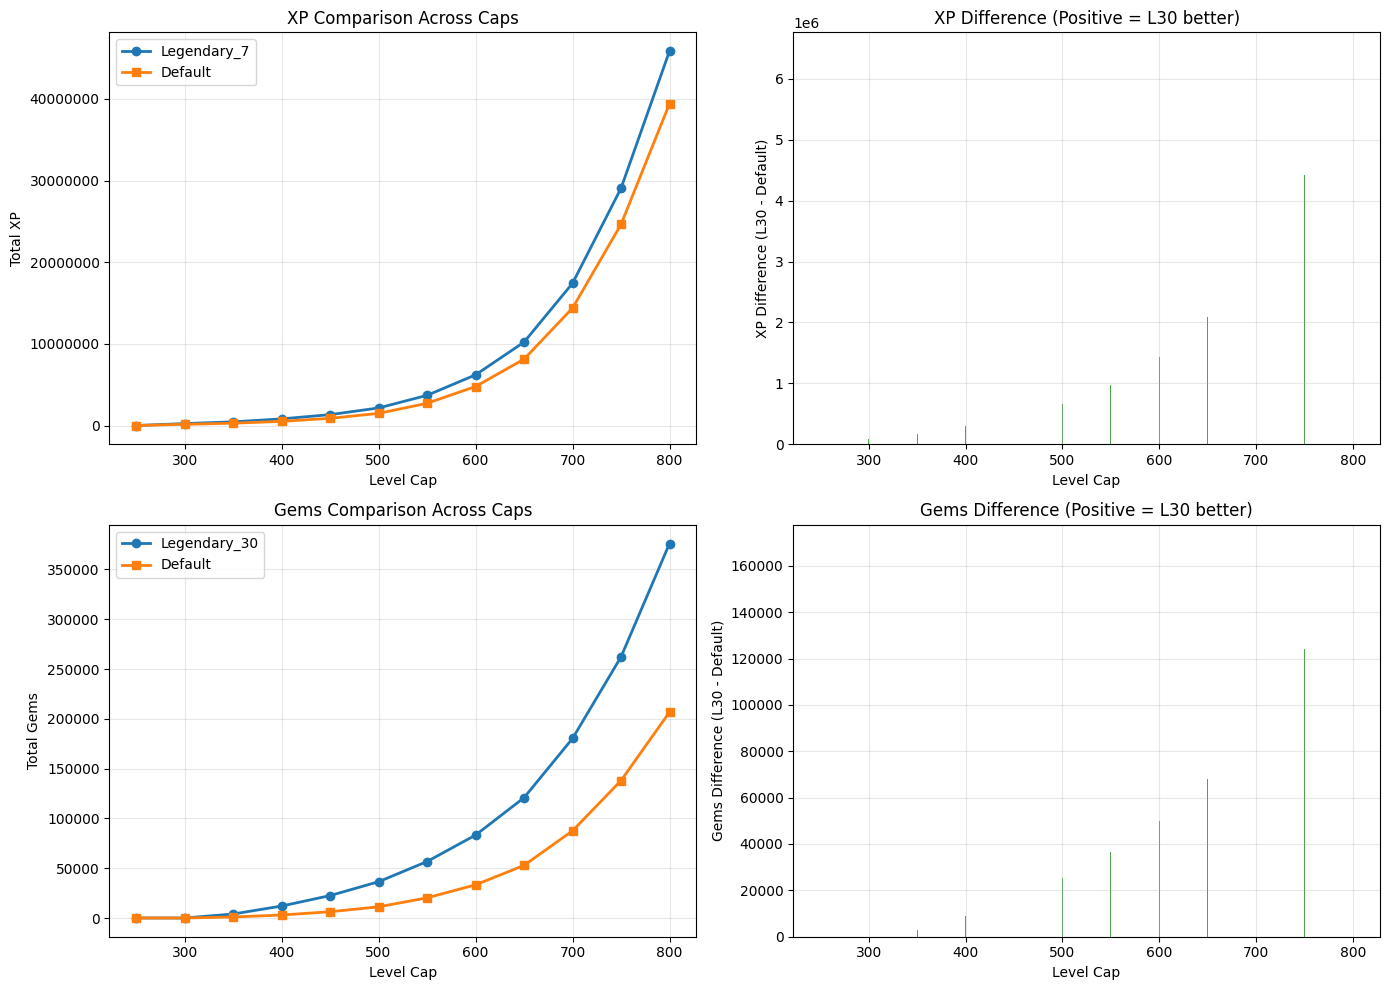

In [177]:
def plot_comparison(df):
    """Create comparison graphs for XP and Gems"""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: XP Comparison
    ax1 = axes[0, 0]
    ax1.plot(df['Level Cap'], df['Legendary_30_XP'], marker='o', label='Legendary_7', linewidth=2)
    ax1.plot(df['Level Cap'], df['Default_XP'], marker='s', label='Default', linewidth=2)
    ax1.set_xlabel('Level Cap')
    ax1.set_ylabel('Total XP')
    ax1.set_title('XP Comparison Across Caps')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.ticklabel_format(style='plain', axis='y')
    
    # Plot 2: XP Difference
    ax2 = axes[0, 1]
    colors = ['green' if x > 0 else 'red' for x in df['XP_Difference']]
    ax2.bar(df['Level Cap'], df['XP_Difference'], color=colors, alpha=0.7)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax2.set_xlabel('Level Cap')
    ax2.set_ylabel('XP Difference (L30 - Default)')
    ax2.set_title('XP Difference (Positive = L30 better)')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Gems Comparison
    ax3 = axes[1, 0]
    ax3.plot(df['Level Cap'], df['Legendary_30_Gems'], marker='o', label='Legendary_30', linewidth=2)
    ax3.plot(df['Level Cap'], df['Default_Gems'], marker='s', label='Default', linewidth=2)
    ax3.set_xlabel('Level Cap')
    ax3.set_ylabel('Total Gems')
    ax3.set_title('Gems Comparison Across Caps')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.ticklabel_format(style='plain', axis='y')
    
    # Plot 4: Gems Difference
    ax4 = axes[1, 1]
    colors = ['green' if x > 0 else 'red' for x in df['Gems_Difference']]
    ax4.bar(df['Level Cap'], df['Gems_Difference'], color=colors, alpha=0.7)
    ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax4.set_xlabel('Level Cap')
    ax4.set_ylabel('Gems Difference (L30 - Default)')
    ax4.set_title('Gems Difference (Positive = L30 better)')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Create plots
plot_comparison(df)

In [178]:
def detailed_table(df):
    """Show composition breakdown for key caps"""
    
    # Select specific caps to display
    key_caps = [250, 400, 550, 700, 750]
    
    detailed_rows = []
    for cap in key_caps:
        row = df[df['Level Cap'] == cap].iloc[0]
        detailed_rows.append({
            'Cap': cap,
            'L30_XP': f"{row['Legendary_30_XP']:,.0f}",
            'L30_Comp': str(row['Legendary_30_Composition']),
            'Default_XP': f"{row['Default_XP']:,.0f}",
            'Default_Comp': str(row['Default_Composition']),
            'XP_Saved': f"{(row['Default_XP'] - row['Legendary_30_XP']):,.0f}"
        })
    
    return pd.DataFrame(detailed_rows)

display(detailed_table(df))

,Cap,L30_XP,L30_Comp,Default_XP,Default_Comp,XP_Saved
0,250,0,"{'Common': 0, 'Rare': 0, 'Epic': 0, 'Legendary...",0,"{'Common': 0, 'Rare': 0, 'Epic': 0, 'Legendary...",0
1,400,"809,520","{'Common': 0, 'Rare': 0, 'Epic': 0, 'Legendary...","507,840","{'Common': 30, 'Rare': 0, 'Epic': 0, 'Legendar...","-301,680"
2,550,"3,694,920","{'Common': 20, 'Rare': 0, 'Epic': 0, 'Legendar...","2,720,100","{'Common': 50, 'Rare': 0, 'Epic': 0, 'Legendar...","-974,820"
3,700,"17,421,350","{'Common': 55, 'Rare': 0, 'Epic': 0, 'Legendar...","14,381,660","{'Common': 85, 'Rare': 0, 'Epic': 0, 'Legendar...","-3,039,690"
4,750,"29,059,310","{'Common': 70, 'Rare': 0, 'Epic': 0, 'Legendar...","24,632,000","{'Common': 100, 'Rare': 0, 'Epic': 0, 'Legenda...","-4,427,310"


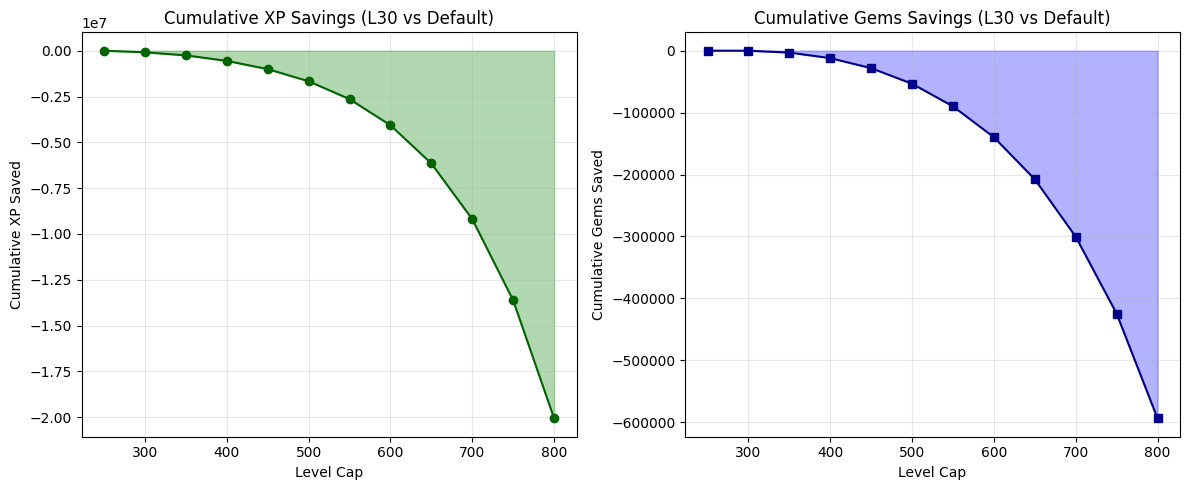

In [179]:
def plot_cumulative_savings(df):
    """Plot cumulative XP and gems saved"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Cumulative XP saved
    cumulative_xp_saved = (df['Default_XP'] - df['Legendary_30_XP']).cumsum()
    ax1.fill_between(df['Level Cap'], 0, cumulative_xp_saved, alpha=0.3, color='green')
    ax1.plot(df['Level Cap'], cumulative_xp_saved, marker='o', color='darkgreen')
    ax1.set_xlabel('Level Cap')
    ax1.set_ylabel('Cumulative XP Saved')
    ax1.set_title('Cumulative XP Savings (L30 vs Default)')
    ax1.grid(True, alpha=0.3)
    
    # Cumulative gems saved
    cumulative_gems_saved = (df['Default_Gems'] - df['Legendary_30_Gems']).cumsum()
    ax2.fill_between(df['Level Cap'], 0, cumulative_gems_saved, alpha=0.3, color='blue')
    ax2.plot(df['Level Cap'], cumulative_gems_saved, marker='s', color='darkblue')
    ax2.set_xlabel('Level Cap')
    ax2.set_ylabel('Cumulative Gems Saved')
    ax2.set_title('Cumulative Gems Savings (L30 vs Default)')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_cumulative_savings(df)

In [180]:
def compare_compositions(costs, unlock_caps, rarity_limits, caps=range(250, 751, 50)):
    """
    Compare three compositions across multiple level caps.
    """
    # Define the 3 situations
    compositions = {
        'Stable_Team(7*L5+commons)': {'Legendary': 7},
        '30_Legendaries': {'Legendary': 30},
        'ALL_Legendaries': {'Legendary': 999}
    }
    
    results = []
    
    for cap in caps:
        row = {'Level Cap': cap}
        
        for name, min_reqs in compositions.items():
            xp, gems, comp = total_cumulative_cost_for_cap(
                costs, unlock_caps, cap, rarity_limits, min_reqs
            )
            row[f'{name}_XP'] = xp
            row[f'{name}_Gems'] = gems
            row[f'{name}_Comp'] = comp
        
        results.append(row)
    
    return pd.DataFrame(results)

# Generate the data
df = compare_compositions(costs, unlock_caps, rarity_limits)

In [181]:
def display_comparison_table(df, caps_to_show=[250, 350, 500, 650, 750]):
    """Display formatted comparison table for selected caps"""
    
    # Filter to selected caps
    df_display = df[df['Level Cap'].isin(caps_to_show)].copy()
    
    # Create formatted display
    display_df = pd.DataFrame()
    display_df['Level Cap'] = df_display['Level Cap']
    
    for name in ['Stable_Team(7*L5+commons)', '30_Legendaries', 'ALL_Legendaries']:
        display_df[f'{name}\nXP'] = df_display[f'{name}_XP'].apply(lambda x: f"{x:,.0f}")
        display_df[f'{name}\nGems'] = df_display[f'{name}_Gems'].apply(lambda x: f"{x:,.0f}")
    
    # Set index for cleaner display
    display_df = display_df.set_index('Level Cap')
    
    return display_df

# Display table
display(display_comparison_table(df))

,Stable_Team(7*L5+commons)\nXP,Stable_Team(7*L5+commons)\nGems,30_Legendaries\nXP,30_Legendaries\nGems,ALL_Legendaries\nXP,ALL_Legendaries\nGems
Level Cap,,,,,,
250,0,0,0,0,0,0
350,"328,322","1,840","448,400","4,000","448,400","4,000"
500,"1,637,878","17,080","2,146,500","36,400","2,367,640","44,800"
650,"8,614,032","68,705","10,212,210","120,800","12,991,650","211,400"
750,"25,665,039","166,980","29,059,310","262,200","39,389,700","552,000"


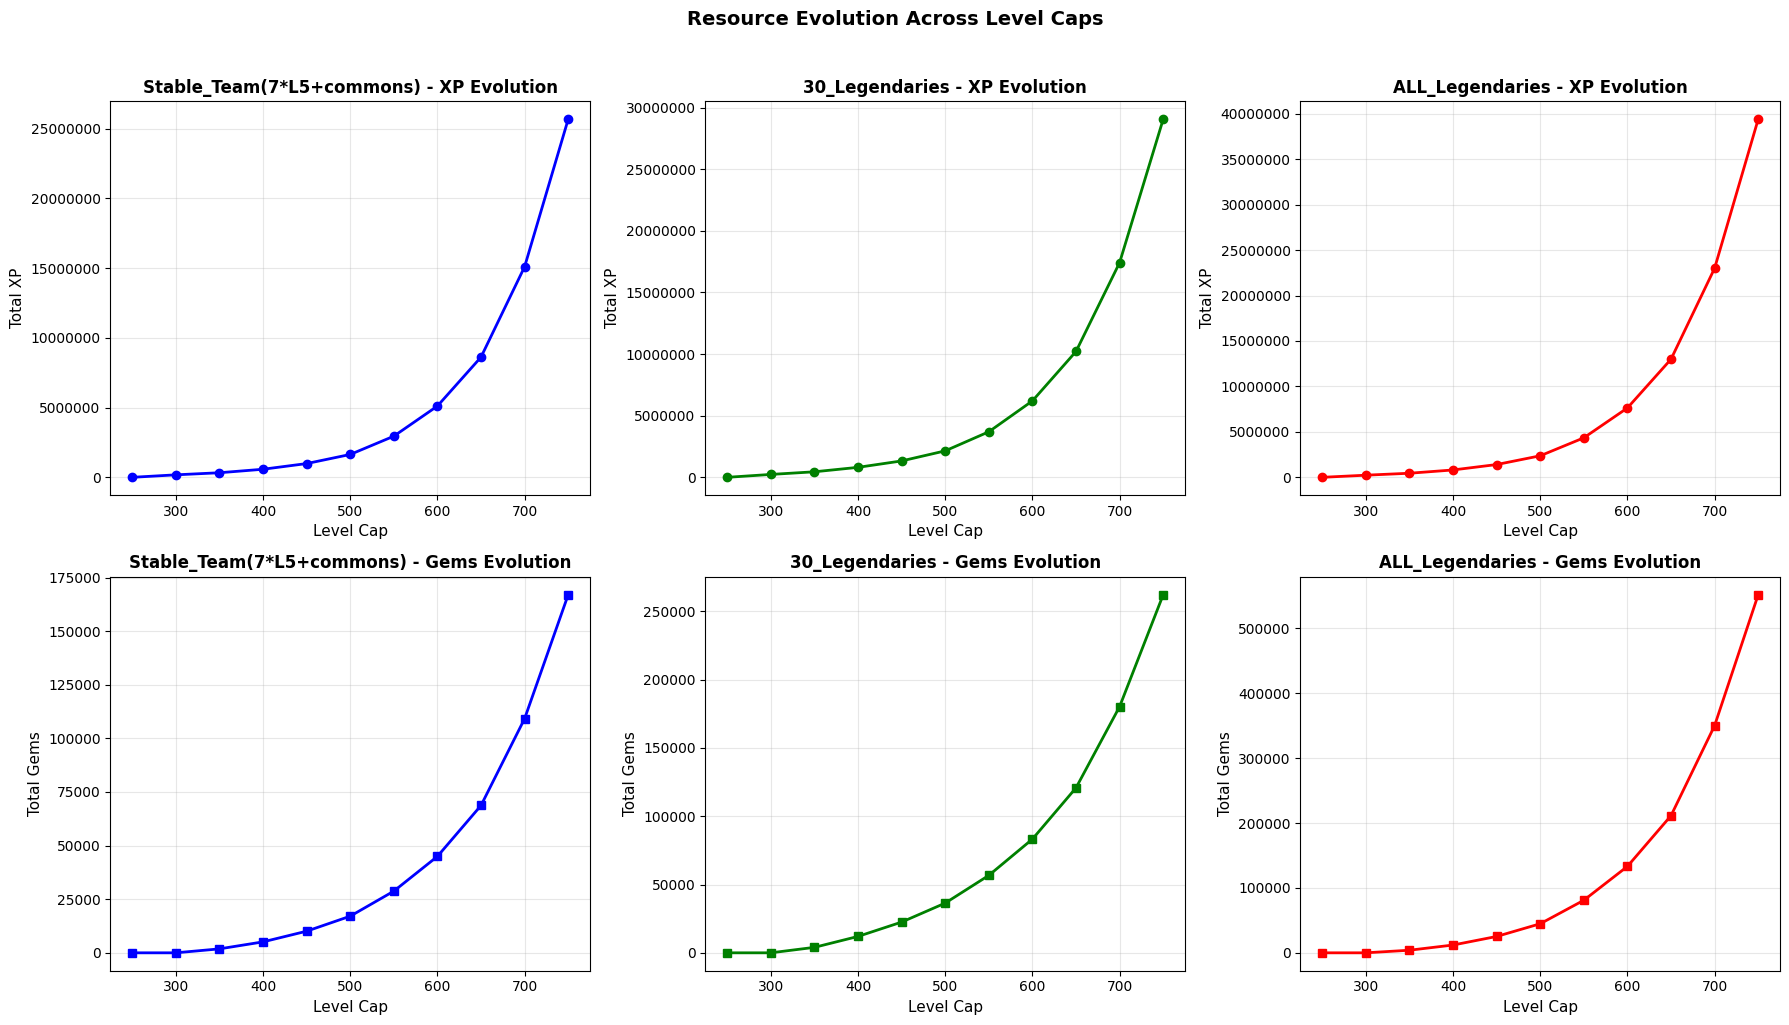

In [182]:
def plot_evolution(df):
    """Create evolution graphs for XP and Gems (3 situations side by side)"""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # XP Evolution (top row)
    compositions = ['Stable_Team(7*L5+commons)', '30_Legendaries', 'ALL_Legendaries']
    colors = ['blue', 'green', 'red']
    
    for i, (comp, color) in enumerate(zip(compositions, colors)):
        ax = axes[0, i]
        ax.plot(df['Level Cap'], df[f'{comp}_XP'], marker='o', color=color, linewidth=2, markersize=6)
        ax.set_xlabel('Level Cap', fontsize=11)
        ax.set_ylabel('Total XP', fontsize=11)
        ax.set_title(f'{comp} - XP Evolution', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.ticklabel_format(style='plain', axis='y')
        
        # Add value labels on points (optional, can remove if too crowded)
        # for idx, row in df.iterrows():
        #     if idx % 2 == 0:  # Show every other cap to avoid clutter
        #         ax.text(row['Level Cap'], row[f'{comp}_XP'], f'{row[f"{comp}_XP"]:,.0f}', 
        #                 fontsize=8, ha='left', va='bottom')
    
    # Gems Evolution (bottom row)
    for i, (comp, color) in enumerate(zip(compositions, colors)):
        ax = axes[1, i]
        ax.plot(df['Level Cap'], df[f'{comp}_Gems'], marker='s', color=color, linewidth=2, markersize=6)
        ax.set_xlabel('Level Cap', fontsize=11)
        ax.set_ylabel('Total Gems', fontsize=11)
        ax.set_title(f'{comp} - Gems Evolution', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.ticklabel_format(style='plain', axis='y')
    
    plt.suptitle('Resource Evolution Across Level Caps', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Create plots
plot_evolution(df)

Saved to images/lvl_cap_unlock_cost.png


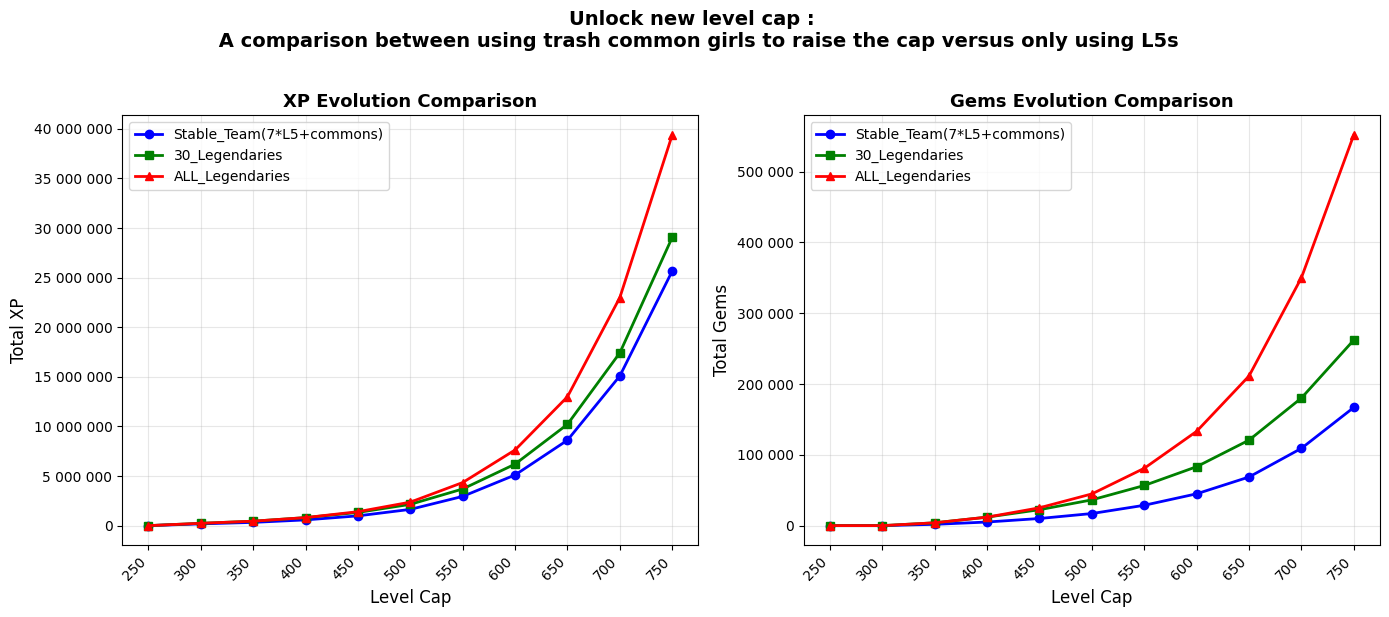

In [196]:
def plot_evolution_combined(df, save_path=None):
    """Plot all 3 situations on same graph for easy comparison"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # XP Evolution
    compositions = ['Stable_Team(7*L5+commons)', '30_Legendaries', 'ALL_Legendaries']
    colors = ['blue', 'green', 'red']
    markers = ['o', 's', '^']
    
    for comp, color, marker in zip(compositions, colors, markers):
        ax1.plot(df['Level Cap'], df[f'{comp}_XP'], marker=marker, color=color, 
                linewidth=2, markersize=6, label=comp)
    ax1.set_xlabel('Level Cap', fontsize=12)
    ax1.set_ylabel('Total XP', fontsize=12)
    ax1.set_title('XP Evolution Comparison', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Format y-axis with format_number
    from matplotlib.ticker import FuncFormatter
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, p: format_number(int(x))))
    
    # Label x-axis at every cap value
    ax1.set_xticks(df['Level Cap'])
    ax1.set_xticklabels([str(cap) for cap in df['Level Cap']])
    
    # Gems Evolution
    for comp, color, marker in zip(compositions, colors, markers):
        ax2.plot(df['Level Cap'], df[f'{comp}_Gems'], marker=marker, color=color,
                linewidth=2, markersize=6, label=comp)
    ax2.set_xlabel('Level Cap', fontsize=12)
    ax2.set_ylabel('Total Gems', fontsize=12)
    ax2.set_title('Gems Evolution Comparison', fontsize=13, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Format y-axis with format_number
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, p: format_number(int(x))))
    
    # Label x-axis at every cap value
    ax2.set_xticks(df['Level Cap'])
    ax2.set_xticklabels([str(cap) for cap in df['Level Cap']])
    
    # Optional: Rotate labels if they overlap
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
    plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
    
    plt.suptitle('Unlock new level cap : \n A comparison between using trash common girls to raise the cap versus only using L5s', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    plt.show()


plot_evolution_combined(df, save_path='images/lvl_cap_unlock_cost.png')

In [191]:
def summary_table(df):
    """Create summary table with final values at max cap"""
    
    max_cap = df['Level Cap'].max()
    final_row = df[df['Level Cap'] == max_cap].iloc[0]
    
    summary = pd.DataFrame({
        'Composition': ['Stable_Team(7*L5+commons)', '30_Legendaries', 'ALL_Legendaries'],
        f'Total XP at {max_cap}': [
            f"{final_row['Stable_Team(7*L5+commons)_XP']:,.0f}",
            f"{final_row['30_Legendaries_XP']:,.0f}",
            f"{final_row['ALL_Legendaries_XP']:,.0f}"
        ],
        f'Total Gems at {max_cap}': [
            f"{final_row['Stable_Team(7*L5+commons)_Gems']:,.0f}",
            f"{final_row['30_Legendaries_Gems']:,.0f}",
            f"{final_row['ALL_Legendaries_Gems']:,.0f}"
        ]
    })
    
    # Add differences relative to Stable_Team(7*L5+commons)
    stable_xp = final_row['Stable_Team(7*L5+commons)_XP']
    stable_gems = final_row['Stable_Team(7*L5+commons)_Gems']
    
    summary['XP vs Stable'] = [
        'Reference',
        f"{((final_row['30_Legendaries_XP'] - stable_xp) / stable_xp * 100):+.1f}%",
        f"{((final_row['ALL_Legendaries_XP'] - stable_xp) / stable_xp * 100):+.1f}%"
    ]
    
    summary['Gems vs Stable'] = [
        'Reference',
        f"{((final_row['30_Legendaries_Gems'] - stable_gems) / stable_gems * 100):+.1f}%",
        f"{((final_row['ALL_Legendaries_Gems'] - stable_gems) / stable_gems * 100):+.1f}%"
    ]
    
    return summary

# Display summary
display(summary_table(df))

,Composition,Total XP at 750,Total Gems at 750,XP vs Stable,Gems vs Stable
0,Stable_Team(7*L5+commons),"25,665,039","166,980",Reference,Reference
1,30_Legendaries,"29,059,310","262,200",+13.2%,+57.0%
2,ALL_Legendaries,"39,389,700","552,000",+53.5%,+230.6%
